In [3]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay)
from sklearn.calibration import CalibratedClassifierCV
import joblib

In [4]:
df=pd.read_csv("spam.csv",encoding='latin-1')[['v1','v2']]
df.columns = ['label', 'message']
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


C:\Users\Rajvi\AppData\Local\Temp\ipykernel_30704\1313659826.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='coolwarm')


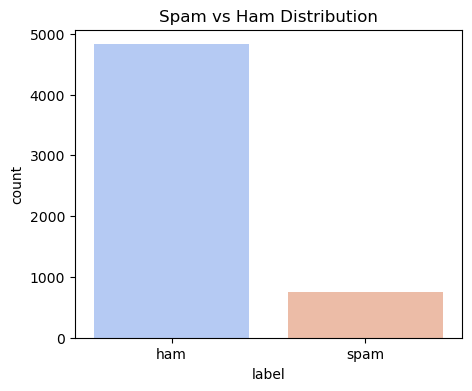

In [5]:
# -------------------------------
# 3. BASIC EDA
# -------------------------------
print("\nDataset Info:")
print(df.info())
print("\nClass Distribution:")
print(df['label'].value_counts())


# Visualize class imbalance
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='coolwarm')
plt.title('Spam vs Ham Distribution')
plt.show()

In [9]:
# -------------------------------
# 4. DATA CLEANING & PREPROCESSING
# -------------------------------
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df['clean_message'] = df['message'].astype(str).apply(clean_text)
df['target'] = df['label'].map({'ham':0, 'spam':1})
print(df.head())

  label                                            message  \
0   ham  Go until jurong point, crazy.. Available only ...   
1   ham                      Ok lar... Joking wif u oni...   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3   ham  U dun say so early hor... U c already then say...   
4   ham  Nah I don't think he goes to usf, he lives aro...   

                                       clean_message  target  
0  go until jurong point crazy available only in ...       0  
1                            ok lar joking wif u oni       0  
2  free entry in 2 a wkly comp to win fa cup fina...       1  
3        u dun say so early hor u c already then say       0  
4  nah i don t think he goes to usf he lives arou...       0  


In [11]:
# -------------------------------
# 5. TRAIN-TEST SPLIT
# -------------------------------
X = df['clean_message']
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 4457 | Test size: 1115


In [13]:
# -------------------------------
# 6. TF-IDF + LOGISTIC REGRESSION PIPELINE
# -------------------------------
from sklearn.pipeline import Pipeline


pipeline = Pipeline([
('tfidf', TfidfVectorizer()),
('clf', LogisticRegression(solver='saga', max_iter=2000, random_state=42))
])
#tfidf is for our testing data and data to be predicted. it will convert the message into tf-idf vectors(numericals). then logistic regression will be applied on those vectors. after that, the messages can be classified into spam and ham using 'clf'


param_grid = {
'tfidf__ngram_range': [(1,1), (1,2)],
'tfidf__max_df': [0.9, 0.95],
'tfidf__min_df': [1, 2],
'tfidf__stop_words': [None, 'english'],
'clf__C': [0.1, 1.0, 10.0],
'clf__penalty': ['l2']
}

In [19]:
# -------------------------------
# 7. MODEL TRAINING (GridSearchCV)
# -------------------------------
print("\nTuning hyperparameters...")


gscv = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
gscv.fit(X_train, y_train)


print("Best Parameters:", gscv.best_params_)
print("Best Cross-Validation F1:", gscv.best_score_)


best_model = gscv.best_estimator_


Tuning hyperparameters...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'clf__C': 10.0, 'clf__penalty': 'l2', 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2), 'tfidf__stop_words': None}
Best Cross-Validation F1: 0.9384988124969139



--- Logistic Regression Performance ---
Accuracy: 0.9865470852017937
Precision: 0.9855072463768116
Recall: 0.912751677852349
F1 Score: 0.9477351916376306
ROC-AUC: 0.9896341378687454

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115



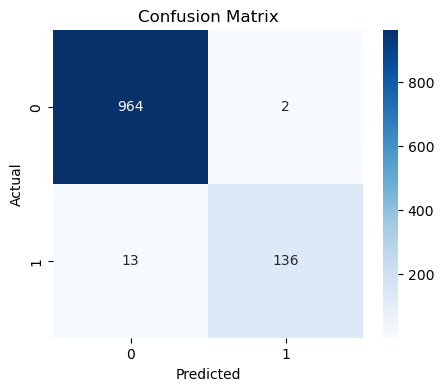

In [16]:
# -------------------------------
# 8. MODEL EVALUATION
# -------------------------------
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]


print("\n--- Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

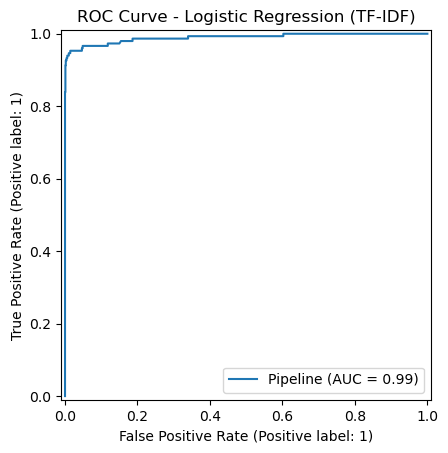

In [17]:
# -------------------------------
# 9. ROC CURVE
# -------------------------------
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title('ROC Curve - Logistic Regression (TF-IDF)')
plt.show()

In [23]:
# -------------------------------
# 10. CALIBRATION (OPTIONAL)
# -------------------------------
calibrator = CalibratedClassifierCV(best_model, method='sigmoid', cv='prefit')
calibrator.fit(X_train, y_train)
calibrated_proba = calibrator.predict_proba(X_test)[:,1]
print("Calibrated ROC-AUC:", roc_auc_score(y_test, calibrated_proba))

Calibrated ROC-AUC: 0.9896341378687454


In [26]:
# -------------------------------
# 11. SAVE MODEL + PIPELINE
# -------------------------------
joblib.dump(best_model, 'spam_logreg_tfidf_pipeline.pkl')
joblib.dump(calibrator, 'spam_logreg_tfidf_calibrated.pkl')
print("\n✅ Model and Calibrator Saved!")


✅ Model and Calibrator Saved!


In [28]:
# -------------------------------
# 12. PREDICT NEW MESSAGES
# -------------------------------
def predict_message(msg, model=best_model):
    clean = clean_text(msg)
    prob = model.predict_proba([clean])[0,1]
    pred = model.predict([clean])[0]
    label = 'SPAM' if pred == 1 else 'HAM'
    return {'Message': msg, 'Cleaned': clean, 'Predicted Label': label, 'Spam Probability': round(prob,3)}


examples = [
"Congratulations! You've won a free iPhone! Click here to claim.",
"Hey, are we still on for dinner tonight?",
"URGENT! You have won a 1-week FREE vacation. Reply YES to claim.",
"ENJOY! 600+ T.V channels."
]


for msg in examples:
    print(predict_message(msg))

{'Message': "Congratulations! You've won a free iPhone! Click here to claim.", 'Cleaned': 'congratulations you ve won a free iphone click here to claim', 'Predicted Label': 'SPAM', 'Spam Probability': 0.845}
{'Message': 'Hey, are we still on for dinner tonight?', 'Cleaned': 'hey are we still on for dinner tonight', 'Predicted Label': 'HAM', 'Spam Probability': 0.011}
{'Message': 'URGENT! You have won a 1-week FREE vacation. Reply YES to claim.', 'Cleaned': 'urgent you have won a 1 week free vacation reply yes to claim', 'Predicted Label': 'SPAM', 'Spam Probability': 0.996}
{'Message': 'ENJOY! 600+ T.V channels.', 'Cleaned': 'enjoy 600 t v channels', 'Predicted Label': 'HAM', 'Spam Probability': 0.111}
